In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("house_price_prediction_dataset.csv")

df.head()

,Area,Bedrooms,Bathrooms,Age,Garage,Quality,Location,SalePrice
0,611.0,4,3.0,49.0,3.0,8,Suburban,415700
1,1941.0,5,2.0,37.0,0.0,10,Coastal,709300
2,815.0,1,4.0,26.0,1.0,9,Downtown,474300
3,938.0,4,1.0,33.0,2.0,5,Rural,310400
4,2399.0,2,NaN,14.0,0.0,10,Urban,644400


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Area       988 non-null    float64
 1   Bedrooms   1000 non-null   int64  
 2   Bathrooms  990 non-null    float64
 3   Age        990 non-null    float64
 4   Garage     992 non-null    float64
 5   Quality    1000 non-null   int64  
 6   Location   990 non-null    str    
 7   SalePrice  1000 non-null   int64  
dtypes: float64(4), int64(3), str(1)
memory usage: 69.1 KB


In [5]:
df.describe()

,Area,Bedrooms,Bathrooms,Age,Garage,Quality,SalePrice
count,988.000000,1000.000000,990.000000,990.000000,992.000000,1000.000000,1.000000e+03
mean,2281.805668,3.590000,2.478788,25.141414,1.554435,5.583000,6.275573e+05
std,993.637009,1.703761,1.137225,14.950346,1.114558,2.814077,1.807093e+05
min,601.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.263000e+05
25%,1456.000000,2.000000,1.000000,12.000000,1.000000,3.000000,4.936250e+05
50%,2224.500000,4.000000,3.000000,25.500000,2.000000,6.000000,6.245500e+05
75%,3145.750000,5.000000,3.000000,38.000000,3.000000,8.000000,7.679000e+05
max,3995.000000,6.000000,4.000000,50.000000,3.000000,10.000000,1.049900e+06


In [6]:
df.isnull().sum()

Area         12
Bedrooms      0
Bathrooms    10
Age          10
Garage        8
Quality       0
Location     10
SalePrice     0
dtype: int64

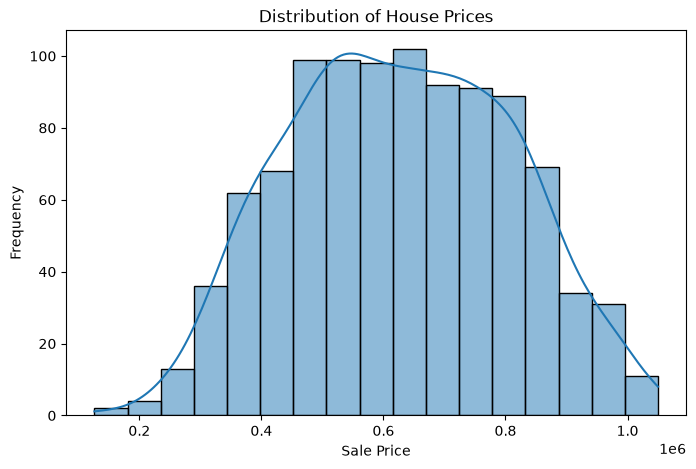

In [7]:
plt.figure(figsize=(8, 5))

sns.histplot(df["SalePrice"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

## Feature Selection Discussion

The main target variable in this project is SalePrice.

The following features are likely to be useful predictors of house prices:

- Area: Larger houses generally have higher prices.
- Bedrooms: The number of bedrooms can affect the value of a property.
- Bathrooms: More bathrooms can increase property value.
- Age: Older houses may have lower prices compared with newer houses.
- Garage: Garage availability and capacity can influence house prices.
- Quality: Higher-quality houses are expected to have higher prices.
- Location: Different locations can have different property price levels.

Both numerical and categorical features will be used. The Location feature is categorical,
so it will be converted into numerical columns using One-Hot Encoding.

In [9]:
correlation = df.select_dtypes(include=np.number).corr()

price_correlation = correlation["SalePrice"].sort_values(ascending=False)

price_correlation

SalePrice    1.000000
Area         0.869588
Quality      0.240911
Bedrooms     0.153699
Bathrooms    0.125047
Garage       0.038381
Age         -0.173454
Name: SalePrice, dtype: float64

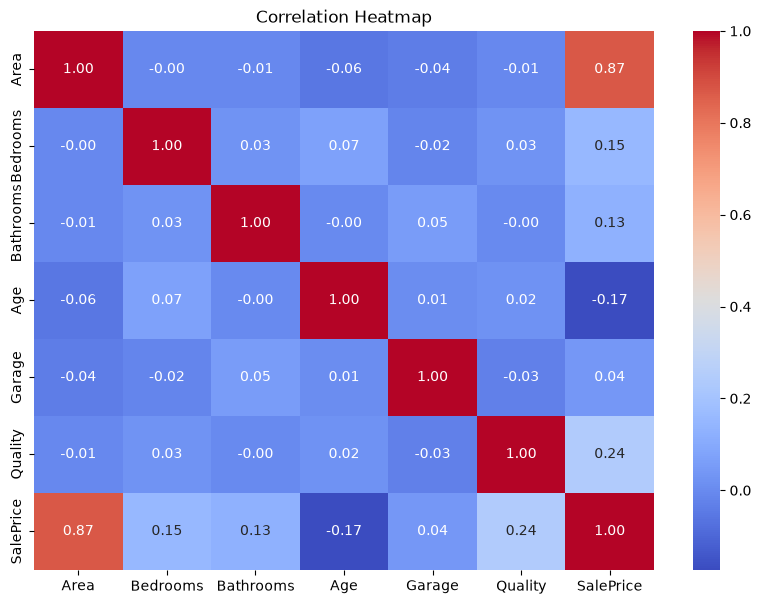

In [10]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [11]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

numerical_features = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Age",
    "Garage",
    "Quality"
]

categorical_features = [
    "Location"
]

print("Features:", X.columns.tolist())
print("Target:", y.name)

Features: ['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Garage', 'Quality', 'Location']
Target: SalePrice


In [12]:
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 7)
Testing data: (200, 7)


In [14]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [15]:
y_pred = linear_model.predict(X_test)

print("Predictions generated successfully!")
print("First 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!
First 10 predictions:
[892068.0201486  402965.11932312 538219.21446084 340903.89010533
 866194.64294067 655687.27967565 332739.68998193 610322.73785783
 412067.23952716 729903.96038837]


In [16]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 2911229823.860099
Root Mean Squared Error (RMSE): 53955.81362429909
R² Score: 0.9151605447585411


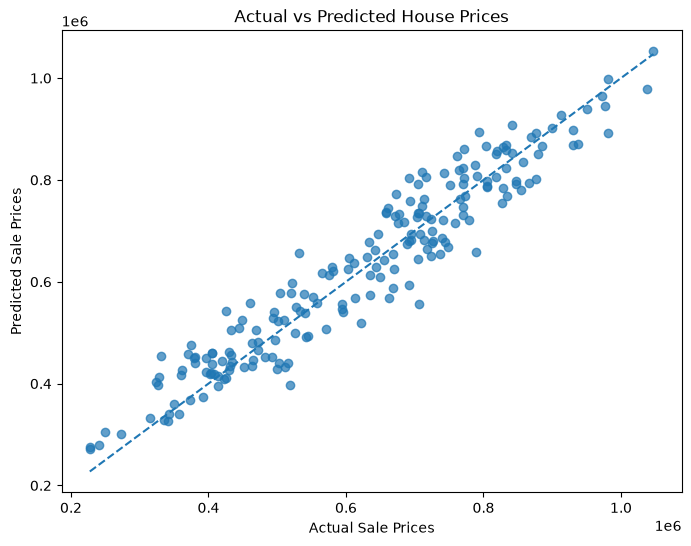

In [17]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Sale Prices")
plt.ylabel("Predicted Sale Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

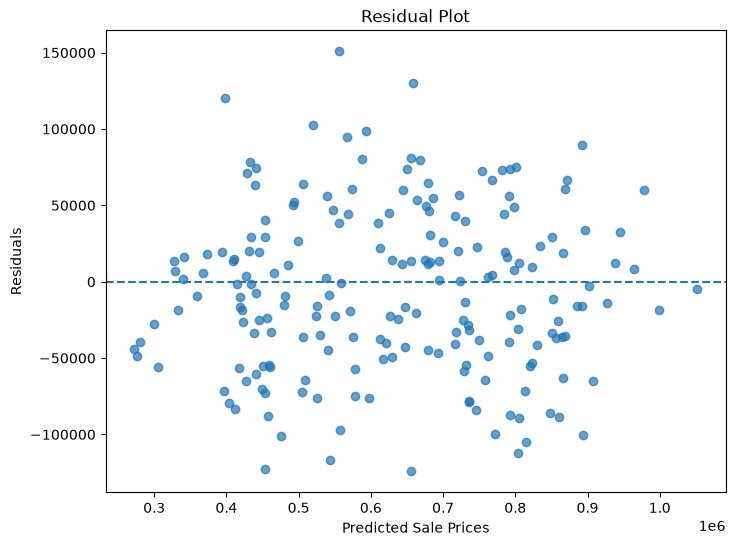

In [18]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.7)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Sale Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [19]:
preprocessor_fitted = linear_model.named_steps["preprocessor"]
regressor = linear_model.named_steps["regressor"]

feature_names = preprocessor_fitted.get_feature_names_out()
coefficients = regressor.coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values("Coefficient", ascending=False)

coef_df

,Feature,Coefficient
6,cat__Location_Coastal,48389.438939
7,cat__Location_Downtown,27309.812822
2,num__Bathrooms,18385.060972
1,num__Bedrooms,16276.862845
5,num__Quality,15219.688978
4,num__Garage,13289.229551
0,num__Area,157.630752
10,cat__Location_Urban,-645.412023
3,num__Age,-1623.910297
9,cat__Location_Suburban,-21383.018784


In [20]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge MSE:", ridge_mse)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R² Score:", ridge_r2)

Ridge MSE: 2914789985.543869
Ridge RMSE: 53988.79499992447
Ridge R² Score: 0.9150567940428309


In [21]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse, ridge_mse],
    "RMSE": [rmse, ridge_rmse],
    "R2 Score": [r2, ridge_r2]
})

comparison

,Model,MSE,RMSE,R2 Score
0,Linear Regression,2.911230e+09,53955.813624,0.915161
1,Ridge Regression,2.914790e+09,53988.795000,0.915057


## Conclusion

In this project, a house price prediction model was developed using Linear Regression.

The dataset was explored using descriptive statistics, missing-value analysis, 
correlation analysis, and a house price distribution plot. Missing numerical values 
were handled using median imputation, while missing categorical values were handled 
using the most frequent value. The Location feature was converted into numerical 
features using One-Hot Encoding.

The data was divided into 80% training data and 20% testing data. Linear Regression 
was used as the main prediction model and evaluated using Mean Squared Error (MSE), 
Root Mean Squared Error (RMSE), and R² Score.

The Linear Regression model achieved an R² score of approximately 0.915, indicating 
that the model explains a large portion of the variation in house prices in this 
dataset.

Ridge Regression was also tested as a bonus model. Its performance was very close 
to Linear Regression.

Actual vs Predicted and Residual plots were used to visually evaluate the model's 
predictions and errors. Coefficient analysis was also performed to understand the 
relationship between the input features and predicted house prices.